# 🏥 🏥 Healthcare Disease Prediction System using Machine Learning
This project uses machine learning algorithms to predict diseases based on symptoms and provide decision support.g.

Key Features:
- Data Cleaning & EDA
- Multiple ML Models Comparison
- Hyperparameter Tuning
- Disease Prediction System
- Basic API Integration

Tools Used: Python, Pandas, Scikit-learn, Matplotlib
"""


## Step 1: Import Libraries
First, we import all the tools (libraries) we need.
Think of this like gathering ingredients before cooking.

In [30]:
# --- Data handling ---
import pandas as pd          # For working with tables (DataFrames)
import numpy as np           # For math operations

# --- Visualization (Charts) ---
import matplotlib.pyplot as plt   # For creating graphs
import seaborn as sns             # For prettier graphs

# --- Machine Learning ---
from sklearn.model_selection import train_test_split    # Split data into train & test
from sklearn.model_selection import cross_val_score     # Test model multiple times
from sklearn.model_selection import GridSearchCV        # Find best model settings
from sklearn.preprocessing import LabelEncoder          # Convert text to numbers

# --- ML Models  ---
from sklearn.ensemble import RandomForestClassifier       # Random Forest
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier           # Decision Tree
from sklearn.neighbors import KNeighborsClassifier        # K-Nearest Neighbors

# --- Evaluation metrics ---
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support


# --- Settings ---
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Dataset
We have 2 CSV files:
1. **dataset.csv** — Diseases and their symptoms (main data)
2. **symptom_precaution.csv** — Precautions for each disease

In [102]:
# Load the two CSV files
df = pd.read_csv("dataset.csv").fillna("None")
precaution = pd.read_csv("symptom_precaution.csv")

# Basic info
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Main dataset : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Precaution   : {precaution.shape[0]} rows x {precaution.shape[1]} columns")
print(f"Total unique diseases: {df['Disease'].nunique()}")
print()
print("First 5 rows:")
df.head()

DATASET OVERVIEW
Main dataset : 4920 rows x 18 columns
Precaution   : 41 rows x 5 columns
Total unique diseases: 41

First 5 rows:


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,None,None,None,None,None,None,None,None,None,None,None,None,None
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,Fungal infection,itching,skin_rash,dischromic _patches,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [10]:
# Check column names and data types
print("Column Details:")
df.info()

Column Details:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB


In [12]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("MISSING VALUES:")
if len(missing_df) > 0:
    print(missing_df.sort_values('Missing %', ascending=False))
else:
    print("No missing values found!")
print(f"Total missing cells: {df.isnull().sum().sum()}")

MISSING VALUES:
            Missing Count  Missing %
Symptom_17           4848      98.54
Symptom_16           4728      96.10
Symptom_15           4680      95.12
Symptom_14           4614      93.78
Symptom_13           4416      89.76
Symptom_12           4176      84.88
Symptom_11           3726      75.73
Symptom_10           3408      69.27
Symptom_9            3228      65.61
Symptom_8            2976      60.49
Symptom_7            2652      53.90
Symptom_6            1986      40.37
Symptom_5            1206      24.51
Symptom_4             348       7.07
Total missing cells: 46992


## Step 3: Clean the Data
Before training, we clean the data:
- Remove extra spaces
- Fill blanks with 'None'
- Remove duplicate rows

In [14]:
print("DATA CLEANING")
print("=" * 50)

# Step 1: Remove extra spaces
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
precaution = precaution.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
print("Step 1: Removed extra spaces")

# Step 2: missing values fill ki
null_count = df.isnull().sum().sum()
df = df.fillna("None")
print(f"Step 2: Filled {null_count} empty cells with 'None'")

# Step 3: Remove duplicate rows
rows_before = df.shape[0]
df = df.drop_duplicates()
print(f"Step 3: Removed {rows_before - df.shape[0]} duplicate rows")

print(f"\nClean dataset: {df.shape[0]} rows, {df['Disease'].nunique()} diseases, 0 missing")

DATA CLEANING
Step 1: Removed extra spaces
Step 2: Filled 46992 empty cells with 'None'
Step 3: Removed 4616 duplicate rows

Clean dataset: 304 rows, 41 diseases, 0 missing


## Step 4: Exploratory Data Analysis (EDA)
Let's create charts to understand our data visually.
### 4.1 — How many records does each disease have?

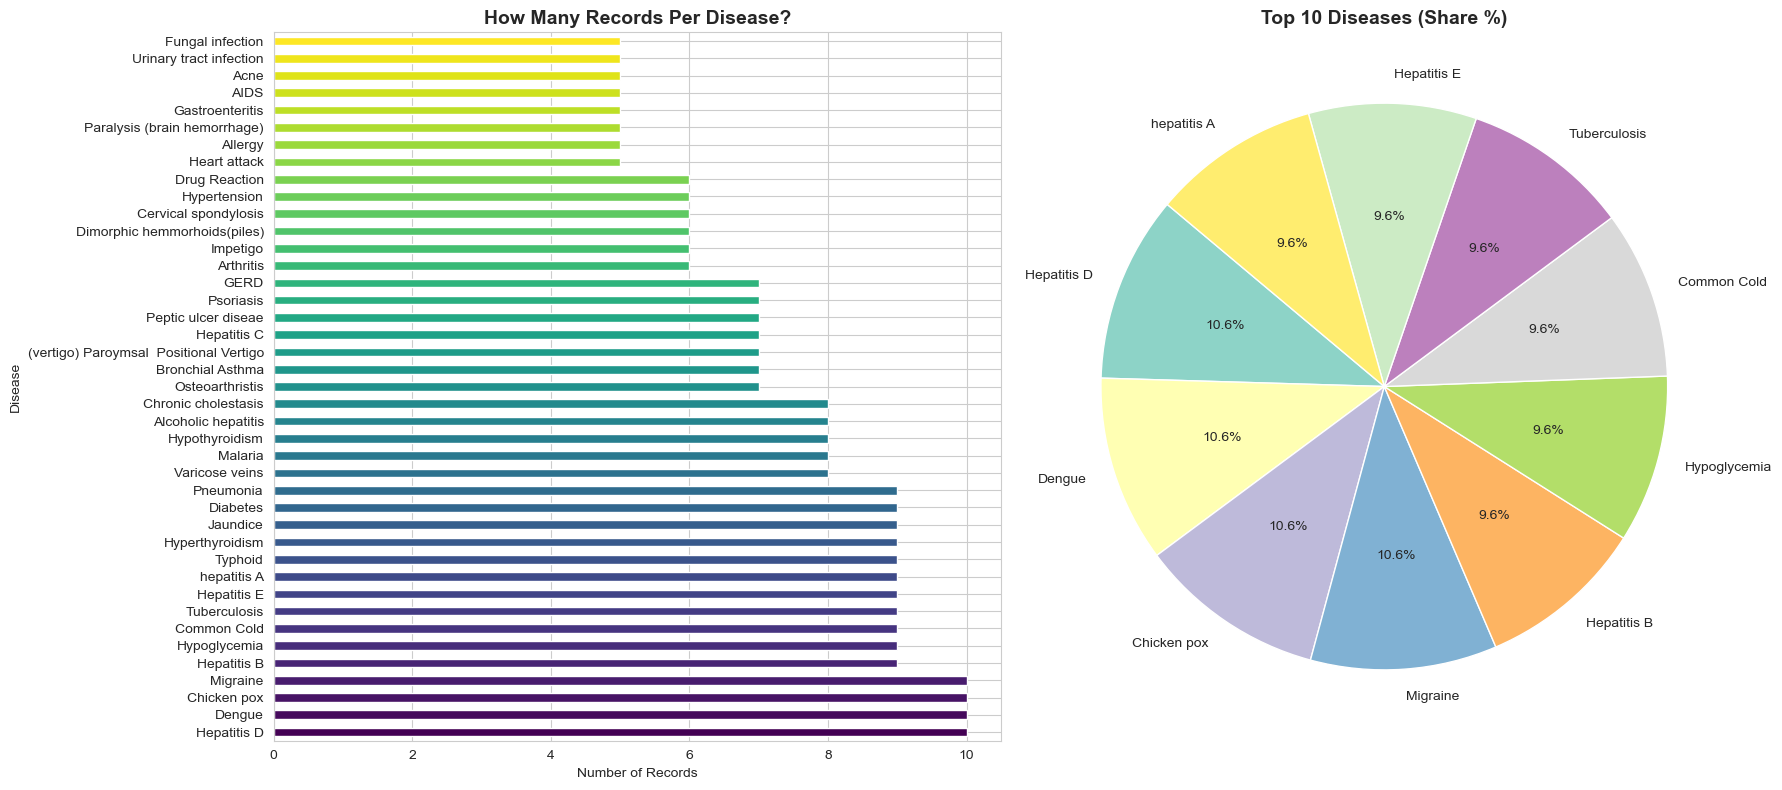

Most common: Hepatitis D (10 records)


In [16]:
disease_counts = df['Disease'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart of all diseases
colors = plt.cm.viridis(np.linspace(0, 1, len(disease_counts)))
disease_counts.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('How Many Records Per Disease?', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Records')

# Pie chart of top 10
top10 = disease_counts.head(10)
axes[1].pie(top10, labels=top10.index, autopct='%1.1f%%', startangle=140,
            colors=plt.cm.Set3(np.linspace(0, 1, 10)))
axes[1].set_title('Top 10 Diseases (Share %)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('disease_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Most common: {disease_counts.index[0]} ({disease_counts.iloc[0]} records)")

### 4.2 — Which symptoms appear most often?

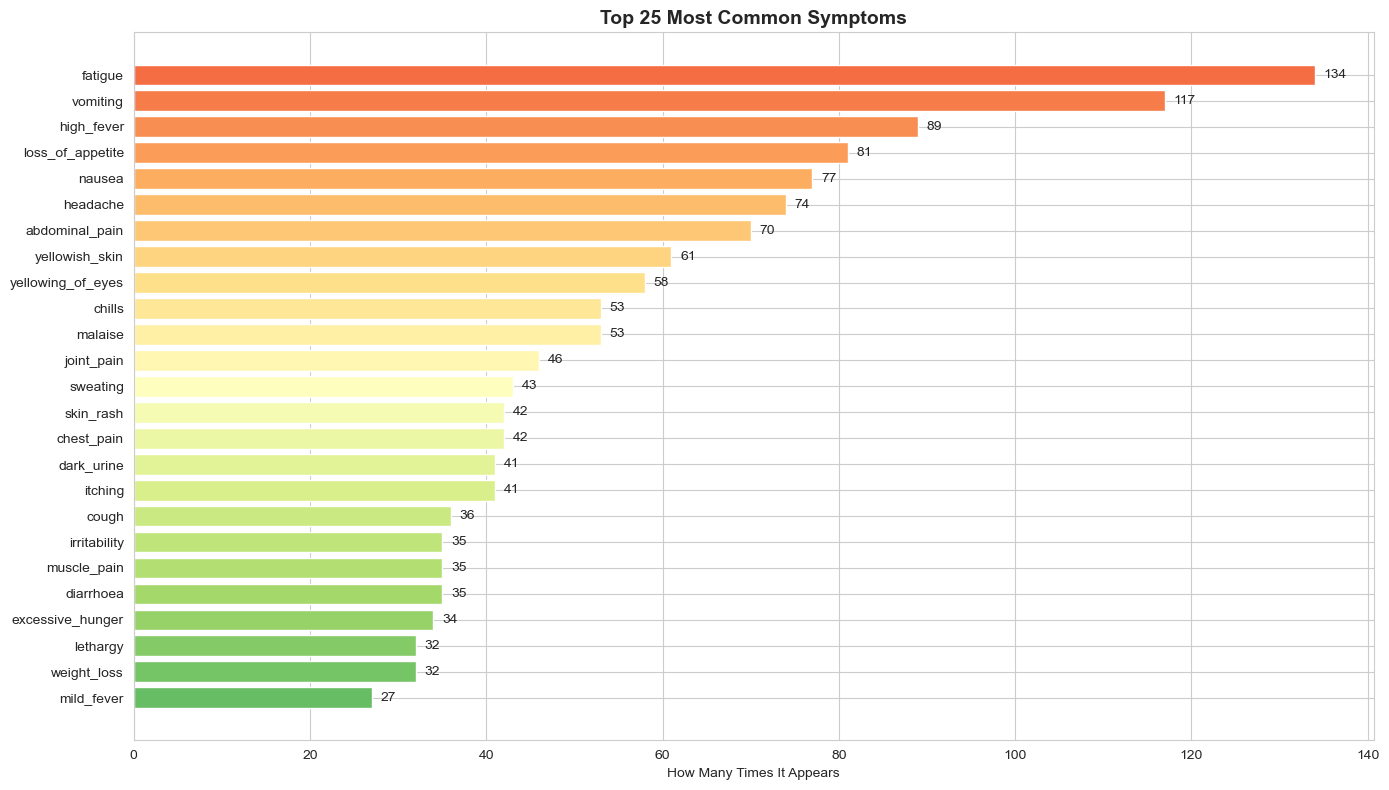

Total unique symptoms: 131


In [18]:
# Collect symptoms from all symptom columns
symptom_cols = [col for col in df.columns if 'Symptom' in col]
all_symptoms = []
for col in symptom_cols:
    symptoms = df[col][df[col] != 'None'].tolist()
    all_symptoms.extend(symptoms)

symptom_freq = pd.Series(all_symptoms).value_counts()

# Plot top 25 symptoms
fig, ax = plt.subplots(figsize=(14, 8))
top25 = symptom_freq.head(25)
ax.barh(range(len(top25)), top25.values, color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, 25)))
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25.index)
ax.set_xlabel('How Many Times It Appears')
ax.set_title('Top 25 Most Common Symptoms', fontsize=14, fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(top25.values):
    ax.text(v + 1, i, str(v), va='center')
plt.tight_layout()
plt.savefig('symptom_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Total unique symptoms: {symptom_freq.shape[0]}")

### 4.3 — Symptom count per disease

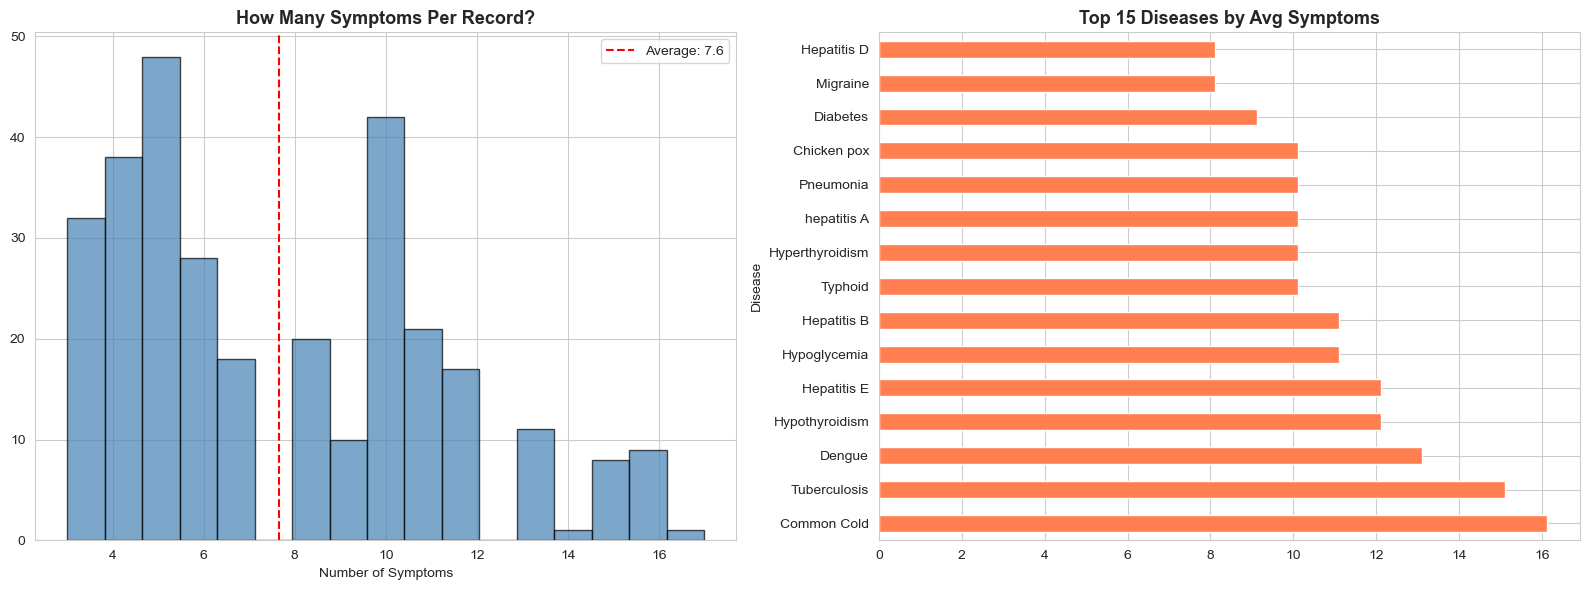

In [20]:
def count_symptoms(row):
    return sum(1 for col in symptom_cols if row[col] != 'None')

df['symptom_count'] = df.apply(count_symptoms, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['symptom_count'].hist(bins=17, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('How Many Symptoms Per Record?', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Symptoms')
axes[0].axvline(df['symptom_count'].mean(), color='red', linestyle='--',
                label=f"Average: {df['symptom_count'].mean():.1f}")
axes[0].legend()

avg_symptoms = df.groupby('Disease')['symptom_count'].mean().sort_values(ascending=False)
avg_symptoms.head(15).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Diseases by Avg Symptoms', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('symptom_count_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
df = df.drop(columns=['symptom_count'])

### 4.5 — Disease Complexity
How many unique symptoms can each disease show? More = harder to diagnose.

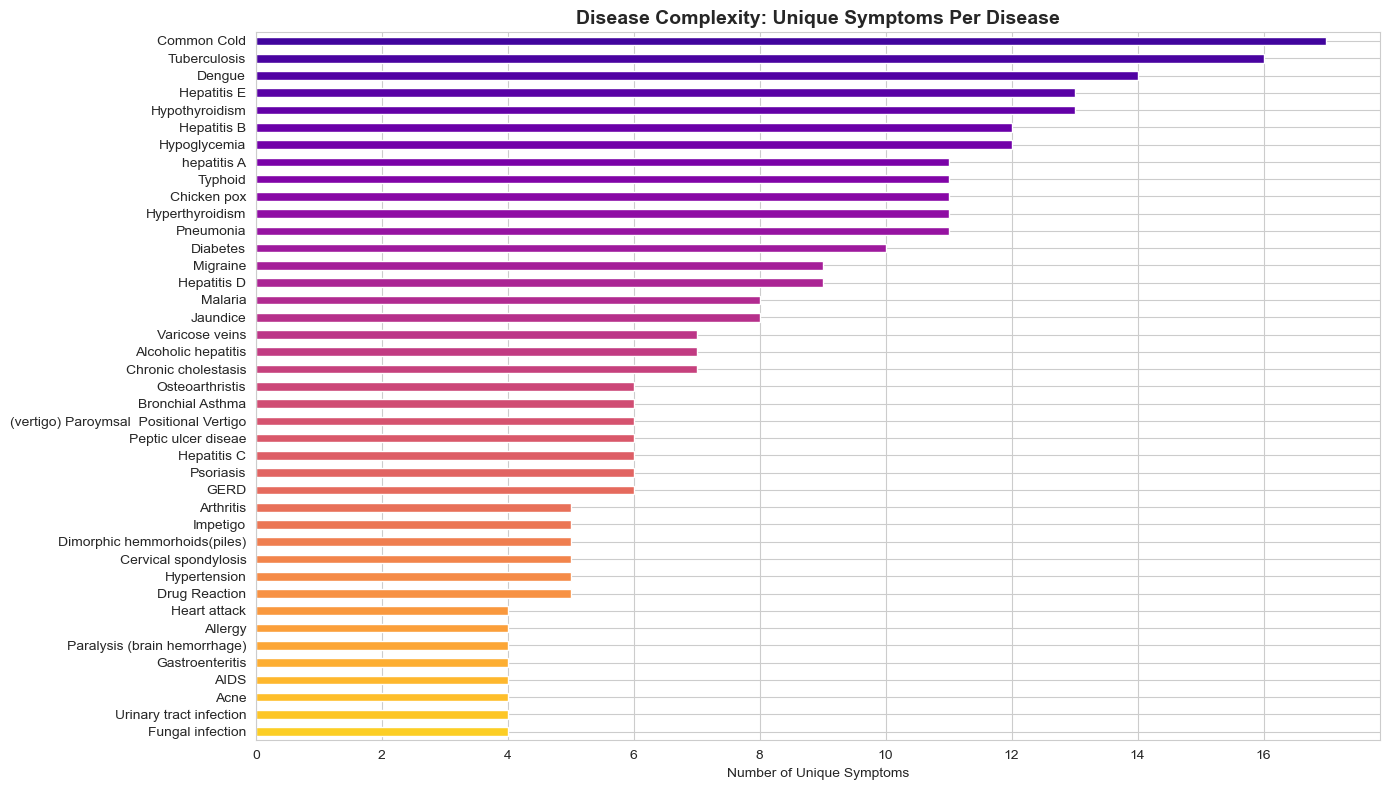

Most complex: Common Cold (17 unique symptoms)
Simplest: Fungal infection (4 unique symptoms)


In [22]:
disease_symptom_sets = {}
for _, row in df.iterrows():
    disease = row['Disease']
    syms = [row[col] for col in symptom_cols if row[col] != 'None']
    if disease not in disease_symptom_sets:
        disease_symptom_sets[disease] = set()
    disease_symptom_sets[disease].update(syms)

complexity = pd.Series({d: len(s) for d, s in disease_symptom_sets.items()}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
complexity.plot(kind='barh', ax=ax, color=plt.cm.plasma(np.linspace(0.1, 0.9, len(complexity))))
ax.set_title('Disease Complexity: Unique Symptoms Per Disease', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Unique Symptoms')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('disease_complexity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Most complex: {complexity.index[0]} ({complexity.iloc[0]} unique symptoms)")
print(f"Simplest: {complexity.index[-1]} ({complexity.iloc[-1]} unique symptoms)")

## Step 5: Convert Text to Numbers (Encoding)
ML models only understand numbers, not text.
So we convert symptom names and disease names into numbers.

Example: "itching" -> 15, "skin_rash" -> 42, "Fungal infection" -> 8

In [24]:
# X = symptoms (input), y = disease (what we predict)
X = df.drop(columns=["Disease"])
y = df["Disease"]

print(f"Features (X): {X.shape} -- {X.shape[1]} symptom columns")
print(f"Target (y): {y.shape} -- {y.nunique()} unique diseases")

# Convert each symptom column from text to numbers
encoders = {}
X_encoded = X.copy()
for col in X.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    encoders[col] = le

# Convert disease names to numbers
disease_encoder = LabelEncoder()
y_encoded = disease_encoder.fit_transform(y)

# Save defaults for prediction
most_common = {col: X[col].mode()[0] for col in X.columns}

print(f"\nEncoded {len(encoders)} symptom columns")
print(f"Encoded {len(disease_encoder.classes_)} diseases")
X_encoded.head()

Features (X): (304, 17) -- 17 symptom columns
Target (y): (304,) -- 41 unique diseases

Encoded 17 symptom columns
Encoded 41 diseases


,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,15,35,35,12,0,0,0,0,0,0,0,0,0,0,0,0,0
1,25,27,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,15,27,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,15,35,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,15,35,35,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Step 6: Split Data (80% Train, 20% Test)
Model learns from 80% of data, then we test it on the remaining 20%.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,        # 20% for testing
    random_state=42,      # Same split every time
    stratify=y_encoded    # Keep disease proportions equal
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_encoded)*100:.0f}%)")
print(f"Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X_encoded)*100:.0f}%)")

Training set: 243 samples (80%)
Testing set:  61 samples (20%)


## Step 7: Train 2 ML Models & Compare

| Model | How it works (Simple) |
|-------|----------------------|
| **Random Forest** | Many decision trees vote together |
| **Decision Tree** | A flowchart of yes/no questions |


In [32]:
# Define all 6 models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()

}

results = {}
print("TRAINING ALL MODELS...")
print("=" * 70)

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Calculate scores
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    cv_scores = cross_val_score(model, X_encoded, y_encoded, cv=5, scoring='accuracy')
    
    results[name] = {
        'accuracy': acc, 'precision': precision, 'recall': recall,
        'f1_score': f1, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'model': model
    }
    
    print(f"\n  {name}")
    print(f"    Accuracy: {acc*100:.2f}% | Precision: {precision*100:.2f}% | F1: {f1*100:.2f}%")
    print(f"    Cross-Val: {cv_scores.mean()*100:.2f}% (+/-{cv_scores.std()*100:.2f}%)")

print("\n" + "=" * 70)
print("All 6 models trained!")

TRAINING ALL MODELS...

  Random Forest
    Accuracy: 90.16% | Precision: 88.80% | F1: 88.31%
    Cross-Val: 89.50% (+/-10.80%)

  Decision Tree
    Accuracy: 83.61% | Precision: 79.23% | F1: 79.73%
    Cross-Val: 68.76% (+/-24.33%)

  Naive Bayes
    Accuracy: 54.10% | Precision: 53.83% | F1: 50.85%
    Cross-Val: 50.37% (+/-21.78%)

  KNN
    Accuracy: 57.38% | Precision: 56.37% | F1: 54.17%
    Cross-Val: 56.60% (+/-12.59%)

All 6 models trained!


## Step 8: Compare All Models

In [38]:
comparison = pd.DataFrame({
    name: {'Test Accuracy': r['accuracy'], 'Precision': r['precision'],
           'Recall': r['recall'], 'F1-Score': r['f1_score'], 'CV Mean': r['cv_mean']}
    for name, r in results.items()
}).T.sort_values('Test Accuracy', ascending=False)

print("MODEL COMPARISON TABLE")
print("=" * 70)
print(comparison.to_string())

best_model_name = comparison['Test Accuracy'].idxmax()
best_accuracy = comparison['Test Accuracy'].max()
print(f"\nBEST MODEL: {best_model_name} (Accuracy: {best_accuracy*100:.2f}%)")
best_model = results[best_model_name]['model']
print(best_model)

MODEL COMPARISON TABLE
               Test Accuracy  Precision    Recall  F1-Score   CV Mean
Random Forest       0.901639   0.887978  0.901639  0.883060  0.894973
Decision Tree       0.836066   0.792350  0.836066  0.797268  0.687596
KNN                 0.573770   0.563661  0.573770  0.541686  0.565956
Naive Bayes         0.540984   0.538251  0.540984  0.508509  0.503716

BEST MODEL: Random Forest (Accuracy: 90.16%)
RandomForestClassifier(random_state=42)


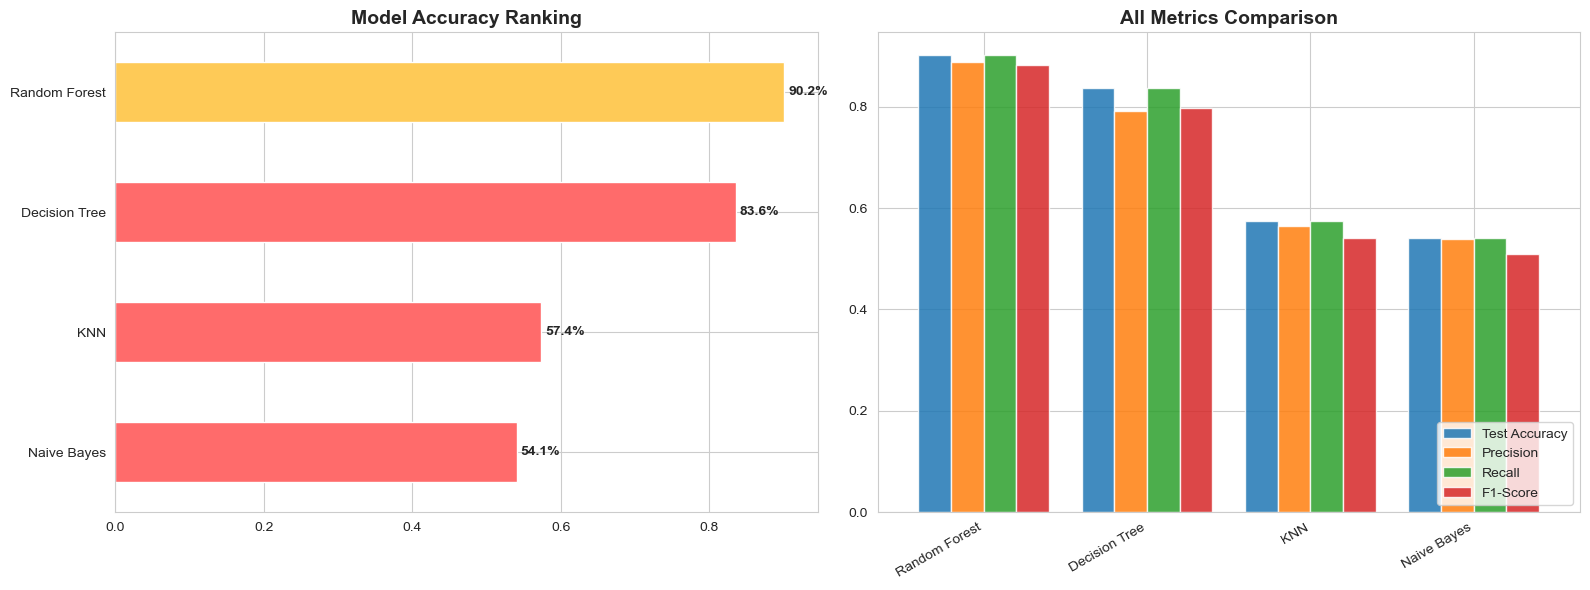

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy ranking
sorted_acc = comparison['Test Accuracy'].sort_values()
colors = ['#48dbfb' if v >= 0.95 else '#feca57' if v >= 0.90 else '#ff6b6b' for v in sorted_acc]
sorted_acc.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Model Accuracy Ranking', fontsize=14, fontweight='bold')
for i, (v, name) in enumerate(zip(sorted_acc.values, sorted_acc.index)):
    axes[0].text(v + 0.005, i, f'{v*100:.1f}%', va='center', fontweight='bold')

# All metrics
comparison[['Test Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=axes[1], width=0.8, alpha=0.85)
axes[1].set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Confusion Matrix
Shows where the model gets confused.
Diagonal = correct, off-diagonal = wrong.

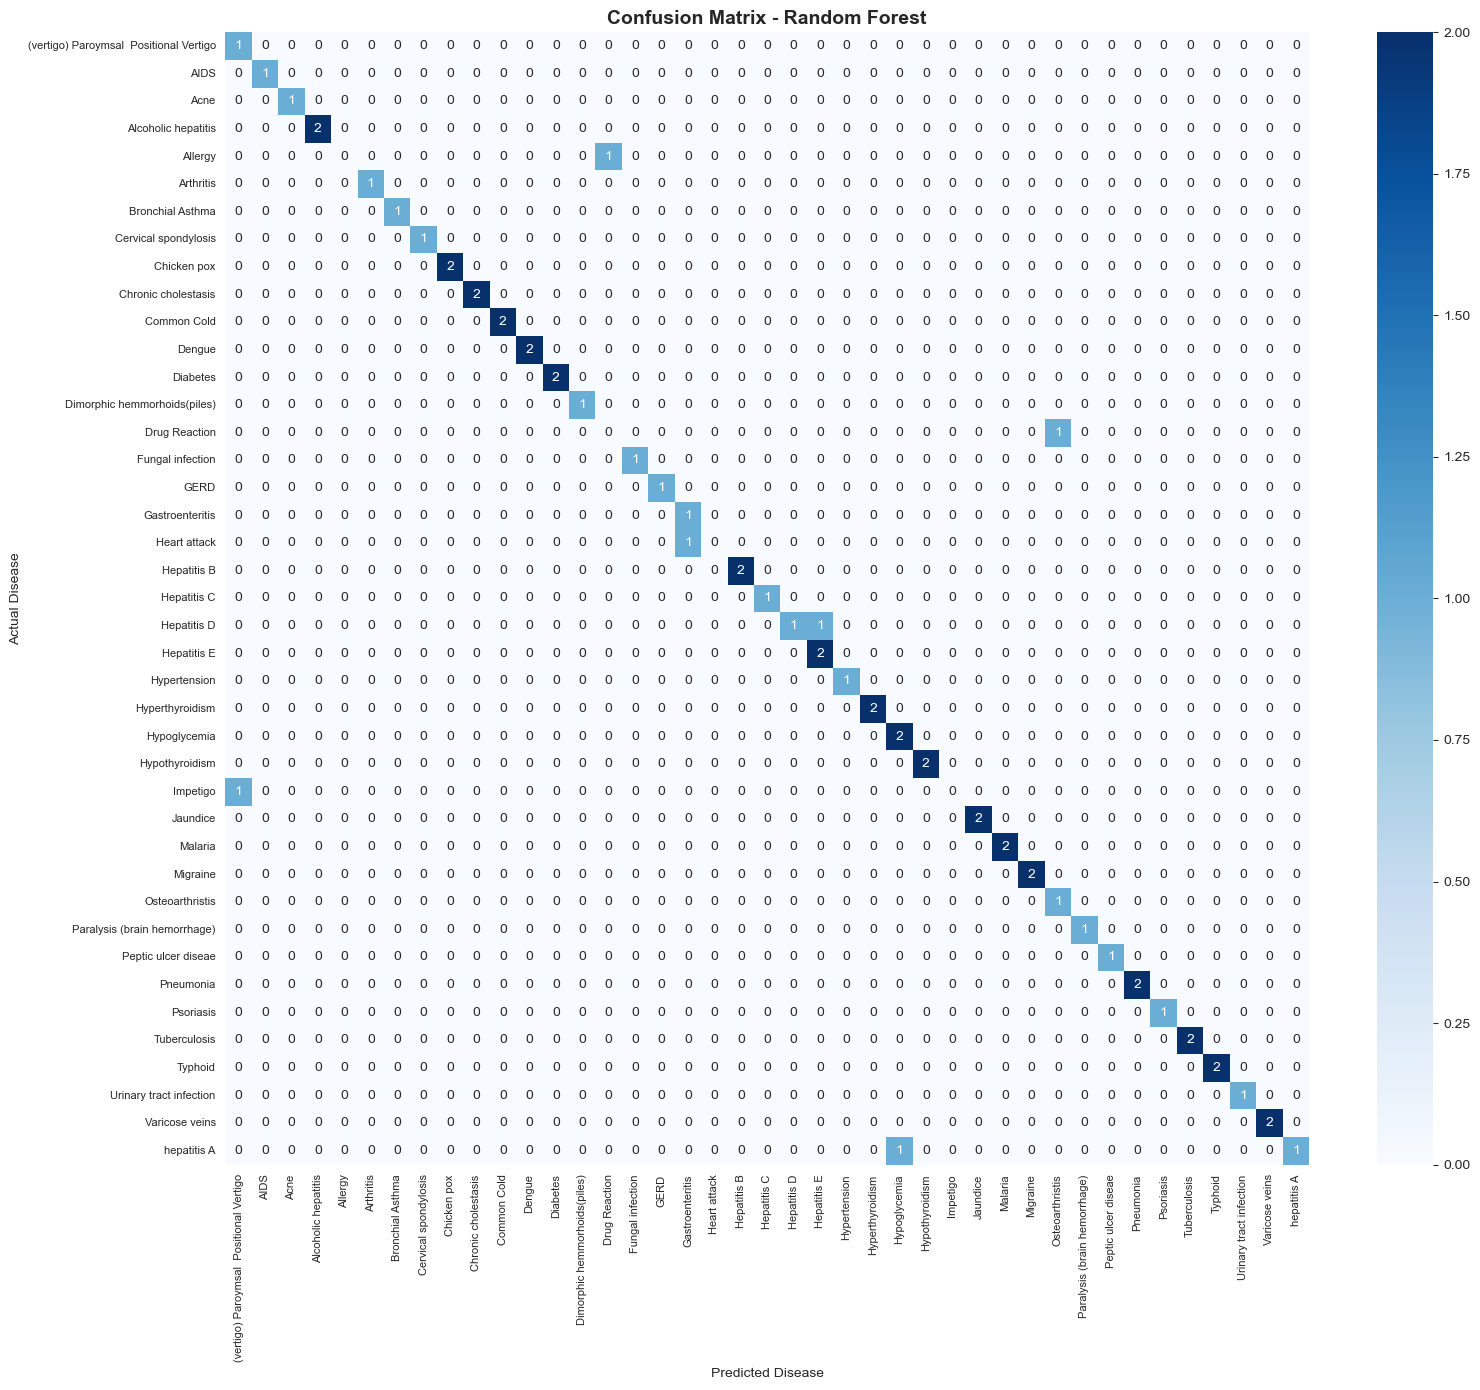

CLASSIFICATION REPORT:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       0.50      1.00      0.67         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         2
                                Allergy       0.00      0.00      0.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         2
                    Chronic cholestasis       1.00      1.00      1.00         2
                            Common Cold       1.00      1.00      1.00         2
    

In [43]:
best_model = results[best_model_name]['model']
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=disease_encoder.classes_, yticklabels=disease_encoder.classes_)
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Disease')
ax.set_ylabel('Actual Disease')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_best, target_names=disease_encoder.classes_))

## Step 11: HYPERPARAMETER TUNING
Which symptom columns help the model most?

In [62]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

tuned_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

y_pred = tuned_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Tuned Accuracy: 0.9344262295081968


## Step 14: Disease Prediction Function
Enter symptoms -> Get top 3 predicted diseases with confidence % and precautions.

In [64]:
# Load precautions into a dictionary
precaution_dict = {}
for _, row in precaution.iterrows():
    disease = row["Disease"].strip().lower()
    precs = row[1:].dropna().tolist()
    precaution_dict[disease] = precs

print(f"Loaded precautions for {len(precaution_dict)} diseases")

Loaded precautions for 41 diseases


In [66]:
def predict_disease(symptoms_list, model=tuned_model, top_n=3):
    # Pad with "None" if fewer symptoms than columns
    while len(symptoms_list) < len(X.columns):
        symptoms_list.append("None")
    symptoms_list = symptoms_list[:len(X.columns)]
    
    # Encode each symptom to number
    input_data = []
    for i, col in enumerate(X.columns):
        symptom = symptoms_list[i].strip().lower().replace(" ", "_")
        le = encoders[col]
        if symptom in le.classes_:
            val = le.transform([symptom])[0]
        else:
            val = le.transform([most_common[col]])[0]
        input_data.append(val)
    
    # Predict
    input_df = pd.DataFrame([input_data], columns=X.columns)
    probabilities = model.predict_proba(input_df)[0]
    top_indices = np.argsort(probabilities)[::-1][:top_n]
    
    predictions = []
    for idx in top_indices:
        disease_name = disease_encoder.inverse_transform([idx])[0]
        confidence = probabilities[idx] * 100
        precs = precaution_dict.get(disease_name.strip().lower(), ["No data available"])
        predictions.append({'disease': disease_name, 'confidence': confidence, 'precautions': precs})
    return predictions

# TEST IT
print("TEST PREDICTION")
print("=" * 50)
test_symptoms = ["itching", "skin_rash", "nodal_skin_eruptions"]
predictions = predict_disease(test_symptoms)

print(f"Input Symptoms: {test_symptoms}")
for i, pred in enumerate(predictions, 1):
    print(f"\n  #{i} {pred['disease']} ({pred['confidence']:.1f}%)")
    for j, p in enumerate(pred['precautions'], 1):
        print(f"     {j}. {p}")

TEST PREDICTION
Input Symptoms: ['itching', 'skin_rash', 'nodal_skin_eruptions', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None']

  #1 Fungal infection (81.0%)
     1. bath twice
     2. use detol or neem in bathing water
     3. keep infected area dry
     4. use clean cloths

  #2 AIDS (5.5%)
     1. avoid open cuts
     2. wear ppe if possible
     3. consult doctor
     4. follow up

  #3 Acne (4.0%)
     1. bath twice
     2. avoid fatty spicy food
     3. drink plenty of water
     4. avoid too many products


## Step 15: Interactive Prediction (User Input)
Uncomment the last line to type your own symptoms.

In [98]:
def predict_from_user():
    print("\nEnter symptoms one by one (type 'done' to finish):")

    user_symptoms = []

    while True:
        s = input(f"Symptom {len(user_symptoms)+1}: ").strip().lower()

        if s == "done":
            break

        user_symptoms.append(s.replace(" ", "_"))

    # pad symptoms
    while len(user_symptoms) < len(X.columns):
        user_symptoms.append("None")

    user_symptoms = user_symptoms[:len(X.columns)]

    input_data = []

    for i, col in enumerate(X.columns):
        symptom = user_symptoms[i]
        le = encoders[col]

        if symptom in le.classes_:
            val = le.transform([symptom])[0]
        else:
            val = le.transform([most_common[col]])[0]

        input_data.append(val)

    # prediction
    input_df = pd.DataFrame([input_data], columns=X.columns)
    pred = tuned_model.predict(input_df)

    disease = disease_encoder.inverse_transform(pred)[0]

    print("\n✅ Predicted Disease:", disease)

In [100]:
predict_from_user()


Enter symptoms one by one (type 'done' to finish):


Symptom 1:  itching
Symptom 2:  skin_rash
Symptom 3:  Acne
Symptom 4:  done



✅ Predicted Disease: Fungal infection


In [109]:
import joblib

joblib.dump(tuned_model, 'disease_prediction_model.pkl')
joblib.dump(encoders, 'symptom_encoders.pkl')
joblib.dump(disease_encoder, 'disease_encoder.pkl')
joblib.dump(most_common, 'most_common_symptoms.pkl')

['most_common_symptoms.pkl']